In [1]:
import fastf1 as ff1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# local cache to avoid repeated downloads
ff1.Cache.enable_cache('./data/cache')

In [2]:
# 2025 Singapore GP Race session
session = ff1.get_session(2025, 'Singapore', 'R')
session.name

session.load()

core           INFO 	Loading data for Singapore Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['63', '1', '4', '81', '12', '16', '14', '44', '87', '55', '6', '22', '18', '23', '30', '43', '5', '31', '10', '27']


# How was Russel in Medium significantly faster than Verstappen in Soft compounds from the race start? 

In [3]:
# lap time data for George Russell 
gr_laps = session.laps.pick_drivers('RUS')
print(gr_laps.shape)
print(gr_laps.columns)
print(gr_laps.describe())

(62, 31)
Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')
                            Time                    LapTime  LapNumber  \
count                         62                         62  62.000000   
mean   0 days 01:46:07.957177419  0 days 00:01:37.134951612  31.500000   
min       0 days 00:56:41.841000     0 days 00:01:35.676000   1.000000   
25%       0 days 01:21:22.394250     0 days 00:01:36.160500  16.250000   
50%       0 days 01:46:18.477000     0 days 00:01:36.660000  31.500000   
75%       0 days 02:10:50.204750     0 days

There are 62 rows (62 laps) with 31 columns


### Investigating performance of each tyre compound

In [4]:
# Get all laps
laps = session.laps 
print(laps.columns)
print(laps.shape)

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')
(1229, 31)


In [5]:
laps.head(5)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:56:41.841000,RUS,63,0 days 00:01:43.905000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.718000,...,True,Mercedes,0 days 00:54:57.735000,2025-10-05 12:03:32.198,1,1.0,False,,False,False
1,0 days 00:58:20.990000,RUS,63,0 days 00:01:39.149000,2.0,1.0,NaT,NaT,0 days 00:00:29.263000,0 days 00:00:41.666000,...,True,Mercedes,0 days 00:56:41.841000,2025-10-05 12:05:16.304,1,1.0,False,,False,True
2,0 days 00:59:59.025000,RUS,63,0 days 00:01:38.035000,3.0,1.0,NaT,NaT,0 days 00:00:28.980000,0 days 00:00:41.190000,...,True,Mercedes,0 days 00:58:20.990000,2025-10-05 12:06:55.453,1,1.0,False,,False,True
3,0 days 01:01:36.595000,RUS,63,0 days 00:01:37.570000,4.0,1.0,NaT,NaT,0 days 00:00:28.833000,0 days 00:00:41.147000,...,True,Mercedes,0 days 00:59:59.025000,2025-10-05 12:08:33.488,1,1.0,False,,False,True
4,0 days 01:03:13.779000,RUS,63,0 days 00:01:37.184000,5.0,1.0,NaT,NaT,0 days 00:00:28.639000,0 days 00:00:40.996000,...,True,Mercedes,0 days 01:01:36.595000,2025-10-05 12:10:11.058,1,1.0,False,,False,True


In [6]:
# remove laps that includes pitting
full_laps = laps[(laps['PitInTime'].isna() & laps['PitOutTime'].isna())]
full_laps.shape

# remove the formation lap
valid_laps = full_laps.drop(full_laps.index[0])
valid_laps.shape

(1180, 31)

Before: 1229 data, After: 1181 data

In [7]:
# convert laptime into seconds
valid_laps = valid_laps.assign(LapTimeSec = valid_laps['LapTime'].dt.total_seconds())
valid_laps['LapTimeSec']

1        99.149
2        98.035
3        97.570
4        97.184
5        96.854
         ...   
1224     96.544
1225     98.014
1226     98.177
1227     99.179
1228    100.195
Name: LapTimeSec, Length: 1180, dtype: float64

In [112]:
# Function for dark theme
def set_dark(ax, facecolor='#222222', text_color='white', spine_color='#bbbbbb'):
    # background color
    ax.set_facecolor(facecolor)
    ax.figure.patch.set_facecolor(facecolor)
    
    # texts color
    ax.tick_params(colors=text_color)
    
    # axes color 
    for spine in ax.spines.values():
        spine.set_color(spine_color)
    
    ax.xaxis.label.set_color(text_color)
    ax.yaxis.label.set_color(text_color)
    ax.title.set_color(text_color)

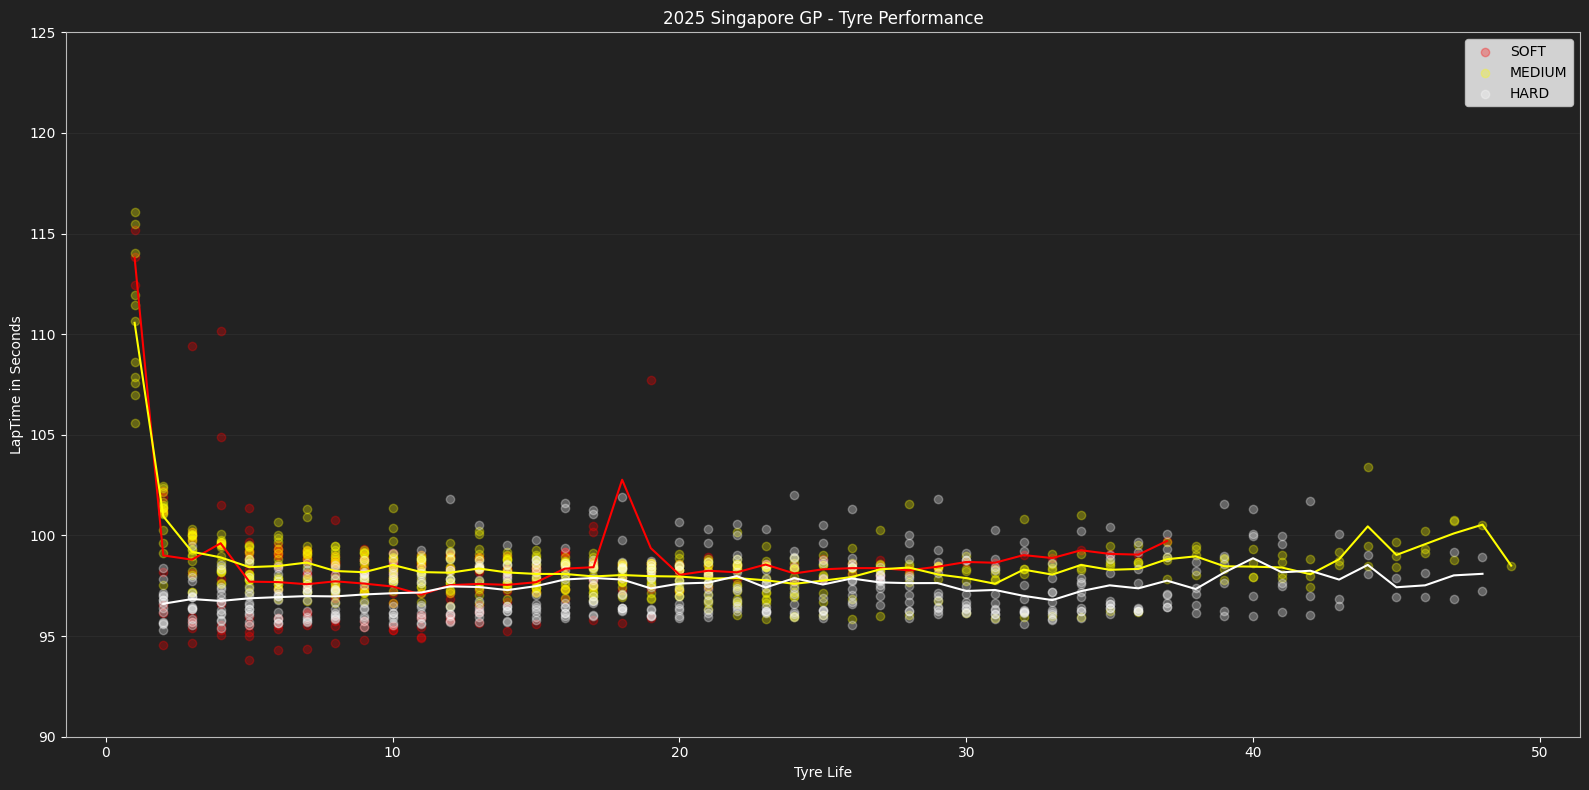

In [113]:
# tyre compounds
compound_colors = {
    'SOFT': 'red',
    'MEDIUM': 'yellow',
    'HARD': 'white'
}

fig, ax = plt.subplots(figsize=(16, 8))

set_dark(ax)

for compound, color in compound_colors.items():
    data = valid_laps.loc[valid_laps['Compound'] == compound]
    # scatter plot for the corresponding tyre compound
    ax.scatter(data['TyreLife'], data['LapTimeSec'], color=color, label=compound, alpha=0.3) 
    # line plot for the mean laptime for each tyre compound for each tyre life
    mean_laptime = data.groupby('TyreLife', as_index=False)['LapTimeSec'].mean()
    ax.plot(mean_laptime['TyreLife'], mean_laptime['LapTimeSec'], color=color)
ax.set_xlabel('Tyre Life')
ax.set_ylabel('LapTime in Seconds')
ax.legend()
ax.set_title('2025 Singapore GP - Tyre Performance')

ax.set_ylim(90, 125)
ax.grid(axis='y', color='gray', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

The visualization above reveals following findings:
- Surprisingly, **HARD compounds** performed better than **SOFT** and **MEDIUM compounds** on average. 
- There are not much difference in terms of performance for different tyre compounds.
- **MEDIUM** and **HARD tyres** had similar maximum lifespan of about 45 ~ 50 laps.

=> __There were little advantage of using SOFT tyres in this GP__

In [9]:
# When did Verstappen PIT?
ver_laps = session.laps.pick_drivers('VER')
ver_laps_pitted = ver_laps.loc[ver_laps.PitInTime.notna()]
ver_laps_pitted.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
80,0 days 01:26:04.389000,VER,1,0 days 00:01:43.287000,19.0,1.0,NaT,0 days 01:25:58.620000,0 days 00:00:28.933000,0 days 00:00:41.202000,...,False,Red Bull Racing,0 days 01:24:21.102000,2025-10-05 12:32:55.565,1,4.0,False,,False,False


Verstappen pitted on 19th lap

In [10]:
ver_laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
62,0 days 00:56:42.823000,VER,1,0 days 00:01:44.887000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:43.146000,...,False,Red Bull Racing,0 days 00:54:57.735000,2025-10-05 12:03:32.198,1,2.0,False,,False,False
63,0 days 00:58:22.521000,VER,1,0 days 00:01:39.698000,2.0,1.0,NaT,NaT,0 days 00:00:29.393000,0 days 00:00:42.236000,...,False,Red Bull Racing,0 days 00:56:42.823000,2025-10-05 12:05:17.286,1,2.0,False,,False,True
64,0 days 01:00:01.002000,VER,1,0 days 00:01:38.481000,3.0,1.0,NaT,NaT,0 days 00:00:29.058000,0 days 00:00:41.689000,...,False,Red Bull Racing,0 days 00:58:22.521000,2025-10-05 12:06:56.984,1,2.0,False,,False,True
65,0 days 01:01:39.079000,VER,1,0 days 00:01:38.077000,4.0,1.0,NaT,NaT,0 days 00:00:28.950000,0 days 00:00:41.465000,...,False,Red Bull Racing,0 days 01:00:01.002000,2025-10-05 12:08:35.465,1,2.0,False,,False,True
66,0 days 01:03:16.583000,VER,1,0 days 00:01:37.504000,5.0,1.0,NaT,NaT,0 days 00:00:28.808000,0 days 00:00:41.160000,...,False,Red Bull Racing,0 days 01:01:39.079000,2025-10-05 12:10:13.542,1,2.0,False,,False,True


In [ ]:
# Convert LapTime to seconds (used .assign to preserve the original)
ver_valid_laps = ver_laps.assign(LapTimeSec = ver_laps['LapTime'].dt.total_seconds())
ver_valid_laps = ver_valid_laps[0:18] # slice from 1st lap to 18th lap

# Russel laps data
rus_laps = session.laps.pick_drivers('RUS')
rus_valid_laps = rus_laps.assign(LapTimeSec = rus_laps['LapTime'].dt.total_seconds())
rus_valid_laps = rus_valid_laps[0:18] # slice from 1st lap to 18th lap

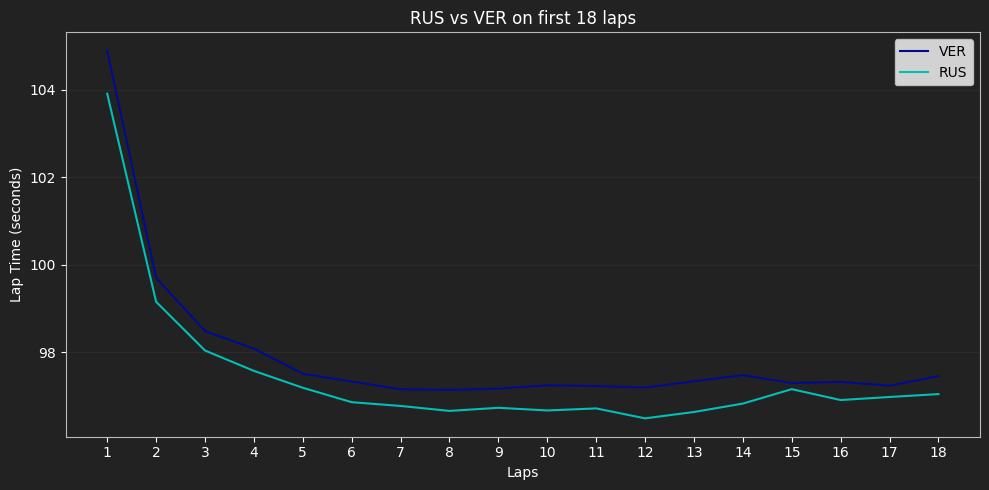

In [114]:
# plot data
driver_colors = {
    'RUS': '#03BFB5',
    'VER': '#000B8D'
}

fig, ax = plt.subplots(figsize=(10, 5))

set_dark(ax)

ax.plot(ver_valid_laps['LapNumber'], ver_valid_laps['LapTimeSec'], color= '#000B8D', label='VER')
ax.plot(rus_valid_laps['LapNumber'], rus_valid_laps['LapTimeSec'], color= '#03BFB5', label='RUS')

ax.set_xlabel('Laps')
ax.set_ylabel('Lap Time (seconds)')
ax.legend()
ax.set_title('RUS vs VER on first 18 laps')

ax.set_xticks(range(1, 19))
ax.grid(axis='y', color='gray', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

- Russel on __MEDIUM__ was significantly faster than Verstappen on __SOFT__ from the start to Verstappen's pit.
- Russel was able to increase gap constantly 

#### Conclusion: There was no point for Red Bull to use **SOFT tyres** from the start, as they did not show conspicuous benefits.

# How dominant was Russel compared to other drivers?

In [66]:
race_result = session.results.copy()
race_result['TeamColor'] = '#' + race_result['TeamColor']
race_result.head()

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
63,63,G RUSSELL,RUS,russell,Mercedes,#00D7B6,mercedes,George,Russell,George Russell,...,1.0,1,1.0,NaT,NaT,NaT,0 days 01:40:22.367000,Finished,25.0,62.0
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,#4781D7,red_bull,Max,Verstappen,Max Verstappen,...,2.0,2,2.0,NaT,NaT,NaT,0 days 00:00:05.430000,Finished,18.0,62.0
4,4,L NORRIS,NOR,norris,McLaren,#F47600,mclaren,Lando,Norris,Lando Norris,...,3.0,3,5.0,NaT,NaT,NaT,0 days 00:00:06.066000,Finished,15.0,62.0
81,81,O PIASTRI,PIA,piastri,McLaren,#F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,4.0,4,3.0,NaT,NaT,NaT,0 days 00:00:08.146000,Finished,12.0,62.0
12,12,K ANTONELLI,ANT,antonelli,Mercedes,#00D7B6,mercedes,Kimi,Antonelli,Kimi Antonelli,...,5.0,5,4.0,NaT,NaT,NaT,0 days 00:00:33.681000,Finished,10.0,62.0


I decided to switch to seaborn (matplotlib was so difficult to achieve side-by-side boxplots)  

- Initial approach using matplotlib: use for loops for each driver to ax.boxplot() 

In [118]:
# I just realized that session.laps has Driver column ordered according to the race result.

# pick_quicklaps(): 
# Return all laps with LapTime faster than a certain limit. By default, the threshold is 107% of the best LapTime of all laps in self. (from fastf1 docs)
laps = session.laps.pick_quicklaps().copy()
laps['LapTimeSec'] = laps['LapTime'].dt.total_seconds()
laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSec
1,0 days 00:58:20.990000,RUS,63,0 days 00:01:39.149000,2.0,1.0,NaT,NaT,0 days 00:00:29.263000,0 days 00:00:41.666000,...,Mercedes,0 days 00:56:41.841000,2025-10-05 12:05:16.304,1,1.0,False,,False,True,99.149
2,0 days 00:59:59.025000,RUS,63,0 days 00:01:38.035000,3.0,1.0,NaT,NaT,0 days 00:00:28.980000,0 days 00:00:41.190000,...,Mercedes,0 days 00:58:20.990000,2025-10-05 12:06:55.453,1,1.0,False,,False,True,98.035
3,0 days 01:01:36.595000,RUS,63,0 days 00:01:37.570000,4.0,1.0,NaT,NaT,0 days 00:00:28.833000,0 days 00:00:41.147000,...,Mercedes,0 days 00:59:59.025000,2025-10-05 12:08:33.488,1,1.0,False,,False,True,97.570
4,0 days 01:03:13.779000,RUS,63,0 days 00:01:37.184000,5.0,1.0,NaT,NaT,0 days 00:00:28.639000,0 days 00:00:40.996000,...,Mercedes,0 days 01:01:36.595000,2025-10-05 12:10:11.058,1,1.0,False,,False,True,97.184
5,0 days 01:04:50.633000,RUS,63,0 days 00:01:36.854000,6.0,1.0,NaT,NaT,0 days 00:00:28.614000,0 days 00:00:40.866000,...,Mercedes,0 days 01:03:13.779000,2025-10-05 12:11:48.242,1,1.0,False,,False,True,96.854


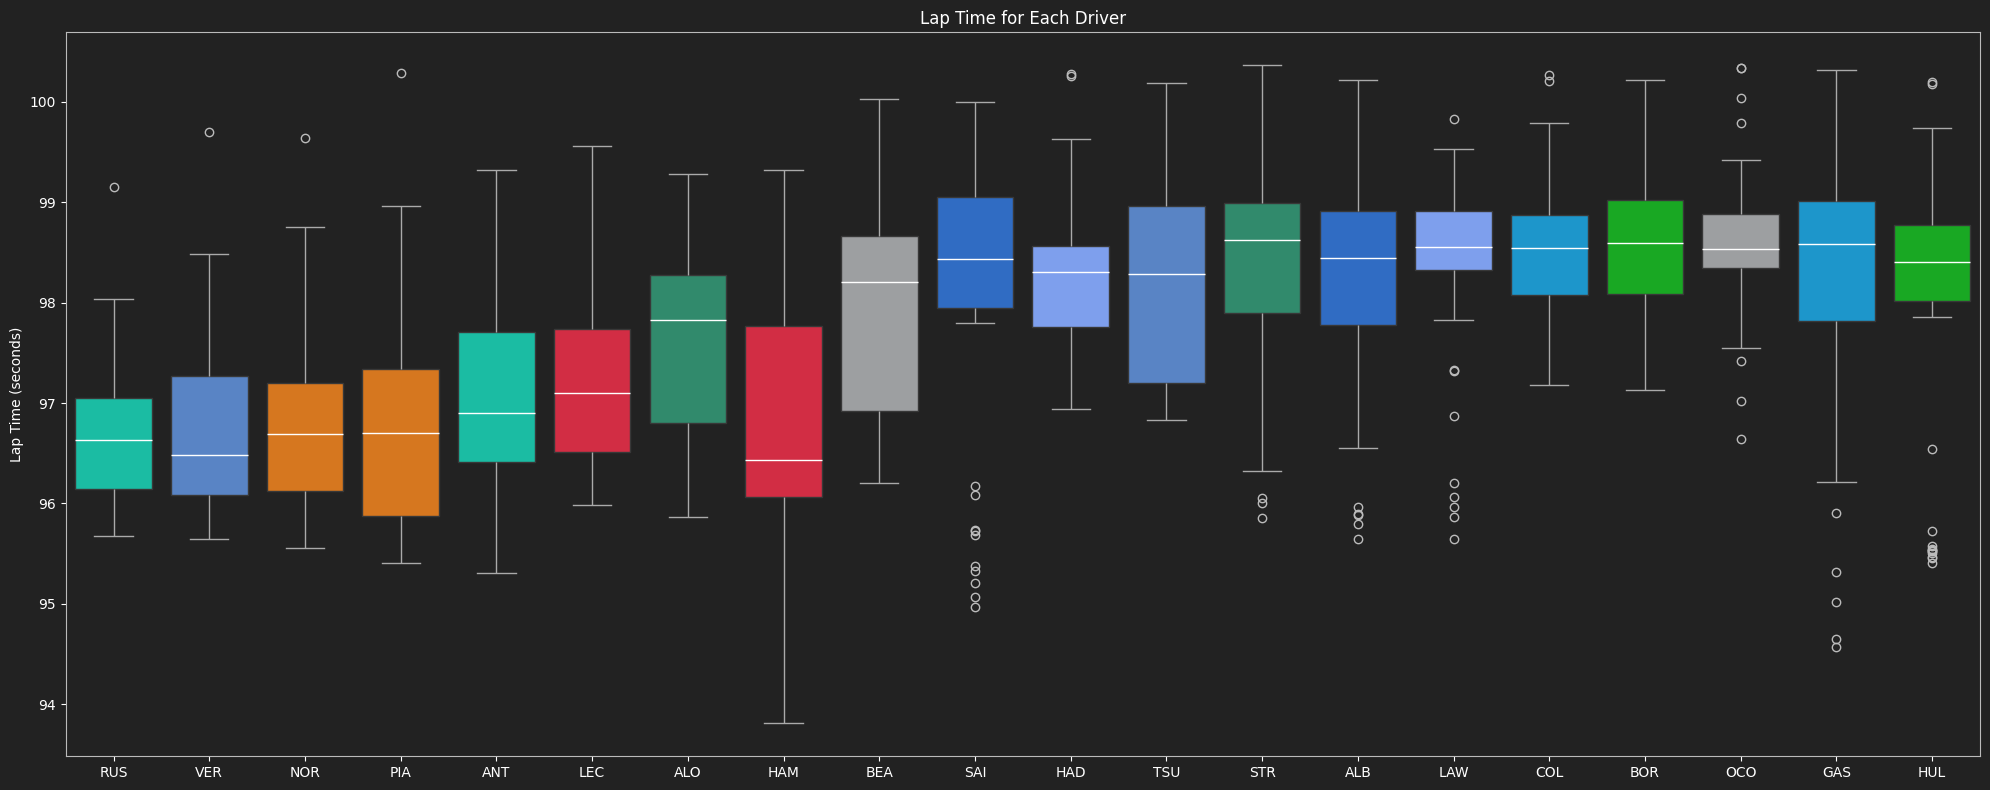

In [119]:
drivers = dict(zip(race_result['Abbreviation'], race_result['TeamColor']))

fig, ax = plt.subplots(figsize=(20, 8))

set_dark(ax)

sns.boxplot(
            x=laps['Driver'],
            y=laps['LapTimeSec'],
            hue=laps['Driver'],
            palette=drivers,
            whiskerprops={'color': '#aaaaaa'},
            capprops={'color': '#aaaaaa'},
            medianprops={'color': 'white'},
            flierprops={'markeredgecolor' :'#bbbbbb'}
            )

ax.set_title('Lap Time for Each Driver')
ax.set_ylabel('Lap Time (seconds)')
ax.set_xlabel('')

plt.tight_layout()
plt.show()

- __RUS__, Mr. Consistency, was the most consistent and fastest driver among the grid. 
- __HAM__ showed extremely inconsistent laps - InterQuartile Range (IQR) is the largest. 
- _Ferrari_ drivers has relatively large IQR. This may be because of LICO (Lift and Coast) for brake cooling, fuel saving, etc.

# How much LICO affected Leclerc ?